# 01 · Data understanding and EDA

Criteo Uplift v2.1 ([Kaggle](https://www.kaggle.com/datasets/arashnic/uplift-modeling),
[Criteo AI Lab](https://ailab.criteo.com/criteo-uplift-prediction-dataset/)): one row per user from randomized
advertising incrementality tests. Full-data numbers come from `uv run causalml eda --mode full`; the code cells
below also run the same functions on the 5% development sample to show what they compute.

**Assignment is not exposure.** `treatment` is the randomized variable (eligible to be shown the advertiser's ads).
`exposure` (actually shown at least one ad) happens after randomization and depends on user activity, so it is an
outcome of treatment, not a second treatment.

In [1]:
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.utils import REPO_ROOT

FIG, TAB, MET = (REPO_ROOT / "results" / d for d in ("figures", "tables", "metrics"))
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
pd.set_option("display.max_colwidth", 120)

def fig(name, width=950):
    display(Image(filename=str(FIG / f"{name}.png"), width=width))

def table(name):
    return pd.read_csv(TAB / f"{name}.csv")

def metrics(name):
    return json.loads((MET / f"{name}.json").read_text())

In [2]:
from src.data.load import load_criteo
from src.data.preprocess import dataset_summary, exposure_funnel, feature_profile, structural_violations
from src.features.build_features import CATEGORICAL, CONTINUOUS

dev = load_criteo("dev")
print(f"development sample: {len(dev):,} rows")
print("structural constraints (T=0 => no exposure, no conversion without a visit):", structural_violations(dev))
dataset_summary(dev, CONTINUOUS, CATEGORICAL)

development sample: 698,977 rows
structural constraints (T=0 => no exposure, no conversion without a visit): {'control_exposed': 0, 'conversion_without_visit': 0}


,metric,value
0,rows,698977
1,n_features,12
2,n_continuous_features,4
3,n_categorical_features,8
4,feature_dtypes,float64
5,label_dtypes,int8
6,missing_values_total,0
7,duplicate_rows_features_and_labels,4143
8,duplicate_rows_features_only,5562
9,control_exposed,0


## Full dataset: summary, variable definitions, feature profile

In [3]:
eda = metrics("eda")
print(f"rows: {eda['rows']:,}   features: {eda['n_features']}   treated share: {eda['treatment_share']:.4f}")
for k, v in eda["variable_definitions"].items():
    print(f"- {k}: {v}")
table("eda_feature_profile")

rows: 13,979,592   features: 12   treated share: 0.8500
- treatment: Randomized assignment: 1 = user eligible to be targeted by the advertiser's ads, 0 = held-out control.
- exposure: 1 = the user was actually shown at least one ad. Post-randomization and self-selected (depends on auctions and user activity), NOT randomized. Zero for every control user.
- visit: Outcome: user visited the advertiser's website within the 2-week test window.
- conversion: Outcome: user converted (purchased) within the 2-week window; implies visit.
- assignment_vs_exposure: Treated-vs-control is the randomized contrast (intention-to-treat, effect of eligibility). Exposed-vs-unexposed compares self-selected groups and is confounded by user activity.


,feature,type,n_unique,mode_value,mode_share,second_mode_share,min,q0.001,q0.01,q0.25,q0.5,q0.75,q0.99,q0.999,max,mean,std,tail_ratio,missing
0,f0,continuous,2181959,12.62,0.2651,6.009e-06,12.62,12.62,12.62,12.62,21.92,24.44,26.67,26.74,26.75,19.62,5.377,0.001534,0
1,f1,categorical,60,10.06,0.9877,0.008815,10.06,10.06,10.06,10.06,10.06,10.06,10.68,11.46,16.34,10.07,0.1048,3.486,0
2,f2,continuous,2051900,8.214,0.5224,1.18e-05,8.214,8.214,8.214,8.214,8.214,8.723,9.043,9.051,9.052,8.447,0.2993,0.000744,0
3,f3,categorical,552,4.68,0.8186,0.04102,-8.398,-3.858,-1.733,4.68,4.68,4.68,4.68,4.68,4.68,4.179,1.337,NaN,0
4,f4,categorical,260,10.28,0.9566,0.02484,10.28,10.28,10.28,10.28,10.28,10.28,11.97,14.62,21.12,10.34,0.3433,1.496,0
5,f5,categorical,132,4.115,0.947,0.0346,-9.012,-0.756,2.231,4.115,4.115,4.115,4.115,4.115,4.115,4.029,0.4311,NaN,0
6,f6,categorical,1645,0.2944,0.2651,0.1597,-31.43,-21.92,-17.78,-6.699,-2.411,0.2944,0.2944,0.2944,0.2944,-4.155,4.578,0,0
7,f7,continuous,622143,4.834,0.947,4.292e-07,4.834,4.834,4.834,4.834,4.834,4.834,11.48,11.96,12,5.102,1.205,0.005975,0
8,f8,categorical,3743,3.972,0.5224,0.06838,3.635,3.705,3.752,3.911,3.972,3.972,3.972,3.972,3.972,3.934,0.05666,NaN,0
9,f9,categorical,1594,13.19,0.795,0.03253,13.19,13.19,13.19,13.19,13.19,13.19,44.89,53.81,75.3,16.03,7.019,0.5289,0


Four features are continuous; eight are hashed categoricals (60 to 3,743 levels) whose numeric values are random
projections, so only their frequency carries order. Most features have a large point mass at one value, and those
point masses come in coupled pairs (same rows), which looks like a shared default value rather than information.

In [4]:
table("eda_mode_coupling")

,feature_a,feature_b,agreement,jaccard
0,f2,f8,1,1
1,f0,f6,1,1
2,f5,f7,1,1
3,f4,f10,1,1
4,f1,f11,0.9764,0.9764
...,...,...,...,...
61,f0,f9,0.2667,0.1822
62,f6,f8,0.2154,0.001858
63,f0,f8,0.2154,0.001858
64,f0,f2,0.2154,0.001858


## Outcomes by randomized arm (descriptive)

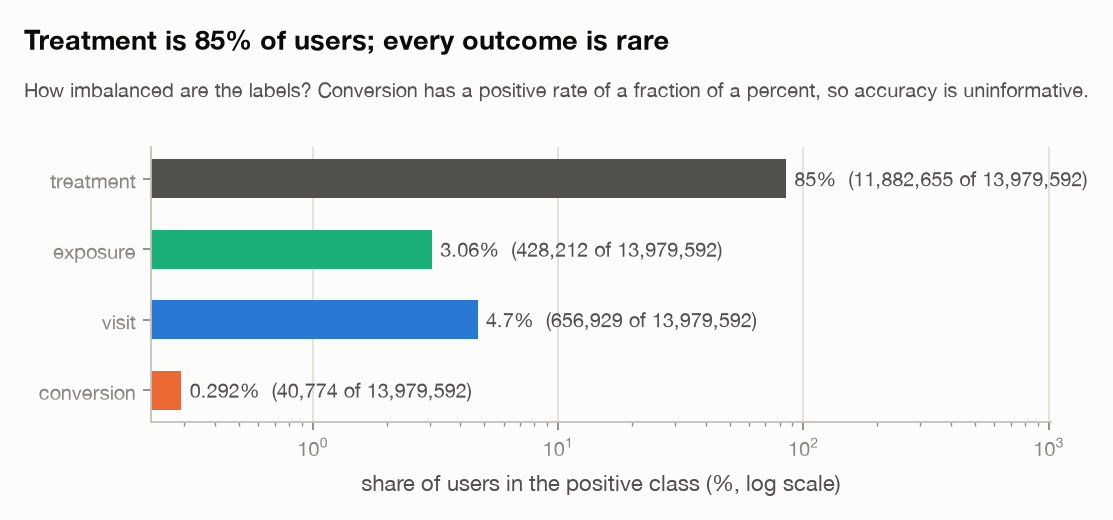

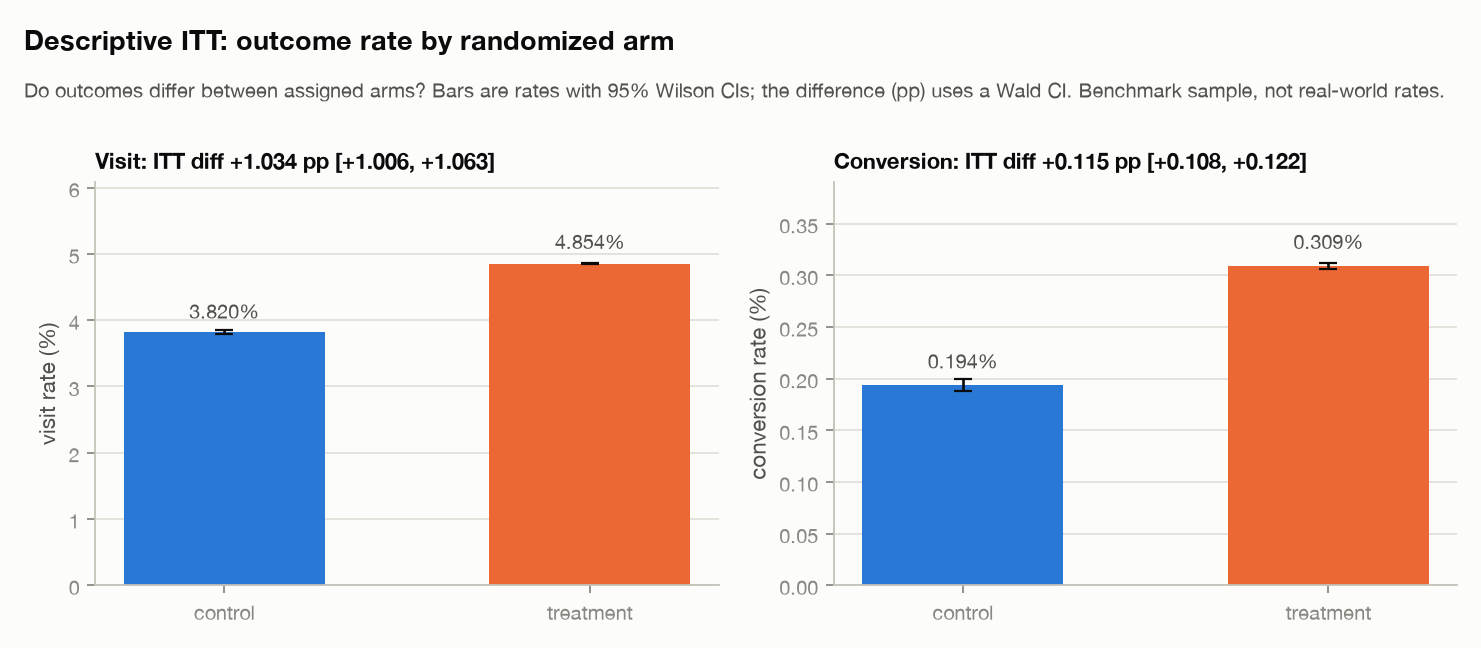

,arm,n,exposure_count,exposure_rate,exposure_ci_low,exposure_ci_high,visit_count,visit_rate,visit_ci_low,visit_ci_high,conversion_count,conversion_rate,conversion_ci_low,conversion_ci_high
0,control,2096937,0,0,1.059e-22,1.832e-06,80105,0.0382,0.03794,0.03846,4063,0.001938,0.001879,0.001998
1,treatment,11882655,428212,0.03604,0.03593,0.03614,576824,0.04854,0.04842,0.04867,36711,0.003089,0.003058,0.003121


In [5]:
fig("eda_target_distribution"); fig("eda_rates_by_arm"); table("eda_rates_by_treatment")

## Why exposure cannot be used as the treatment

Only a small share of treated users is ever shown an ad, and those users are far more active. Treated users who
were *not* exposed convert below the control group, which is impossible if exposure were random. Comparing exposed
with unexposed users therefore measures who gets shown ads, not what ads do.

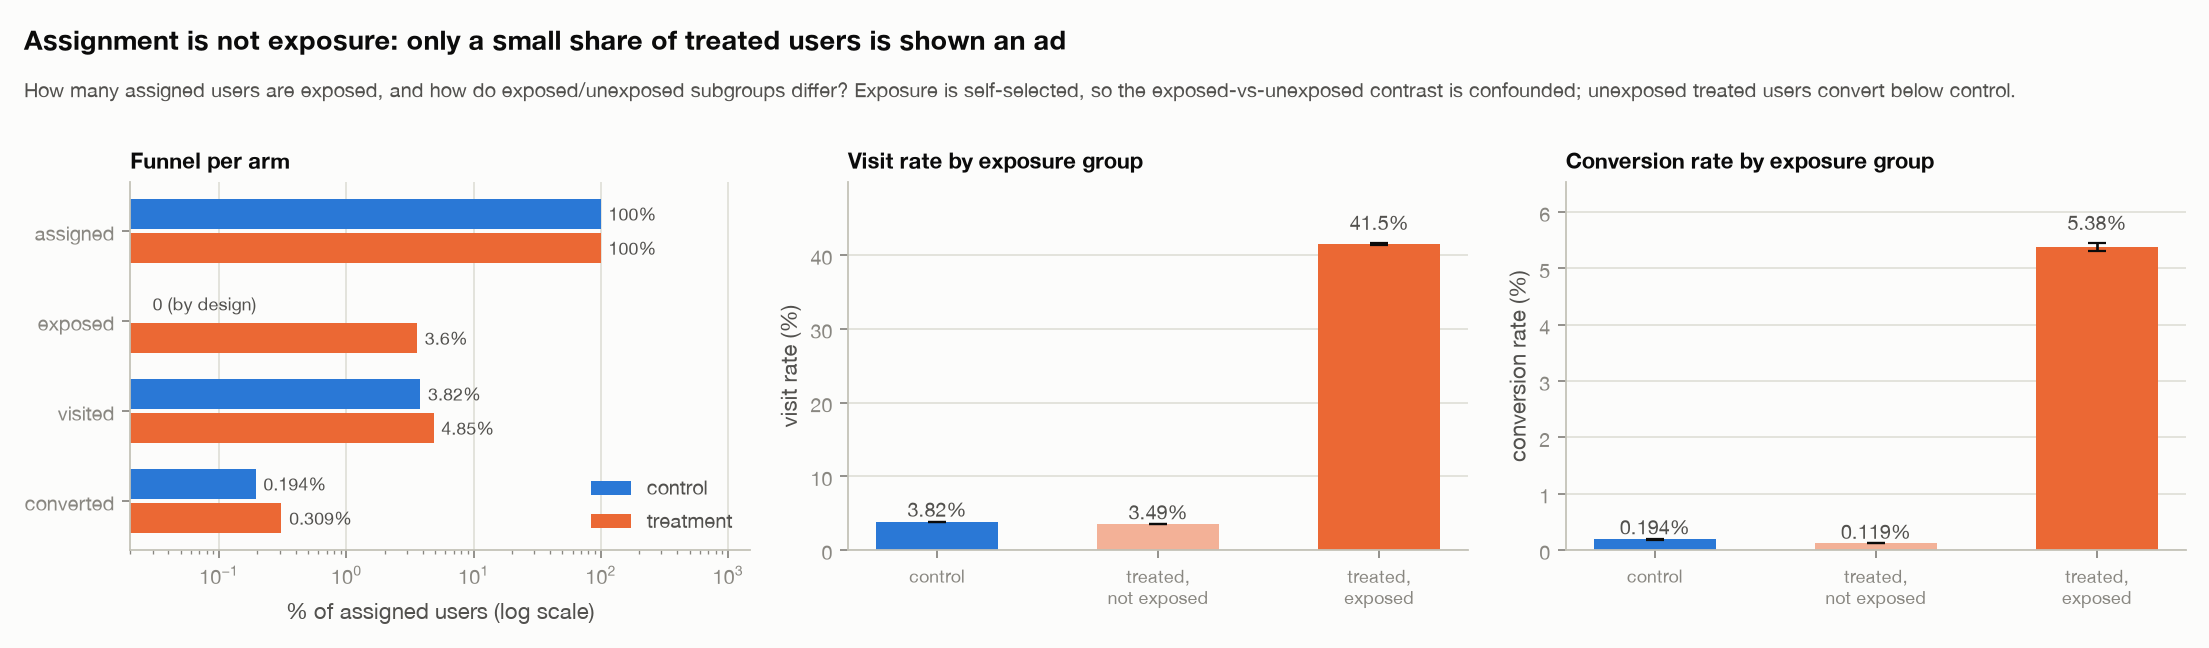

,group,n,share_of_treated,exposure_count,exposure_rate,exposure_ci_low,exposure_ci_high,visit_count,visit_rate,visit_ci_low,visit_ci_high,conversion_count,conversion_rate,conversion_ci_low,conversion_ci_high
0,control,2096937,NaN,0,0,1.059e-22,1.832e-06,80105,0.0382,0.03794,0.03846,4063,0.001938,0.001879,0.001998
1,treated,11882655,1,428212,0.03604,0.03593,0.03614,576824,0.04854,0.04842,0.04867,36711,0.003089,0.003058,0.003121
2,treated_exposed,428212,0.03604,428212,1,1,1,177510,0.4145,0.4131,0.416,23031,0.05378,0.05311,0.05446
3,treated_unexposed,11454443,0.964,0,0,2.647e-23,3.354e-07,399314,0.03486,0.03475,0.03497,13680,0.001194,0.001174,0.001214


In [6]:
fig("eda_exposure_funnel"); table("eda_exposure_funnel")

## Covariate balance between arms

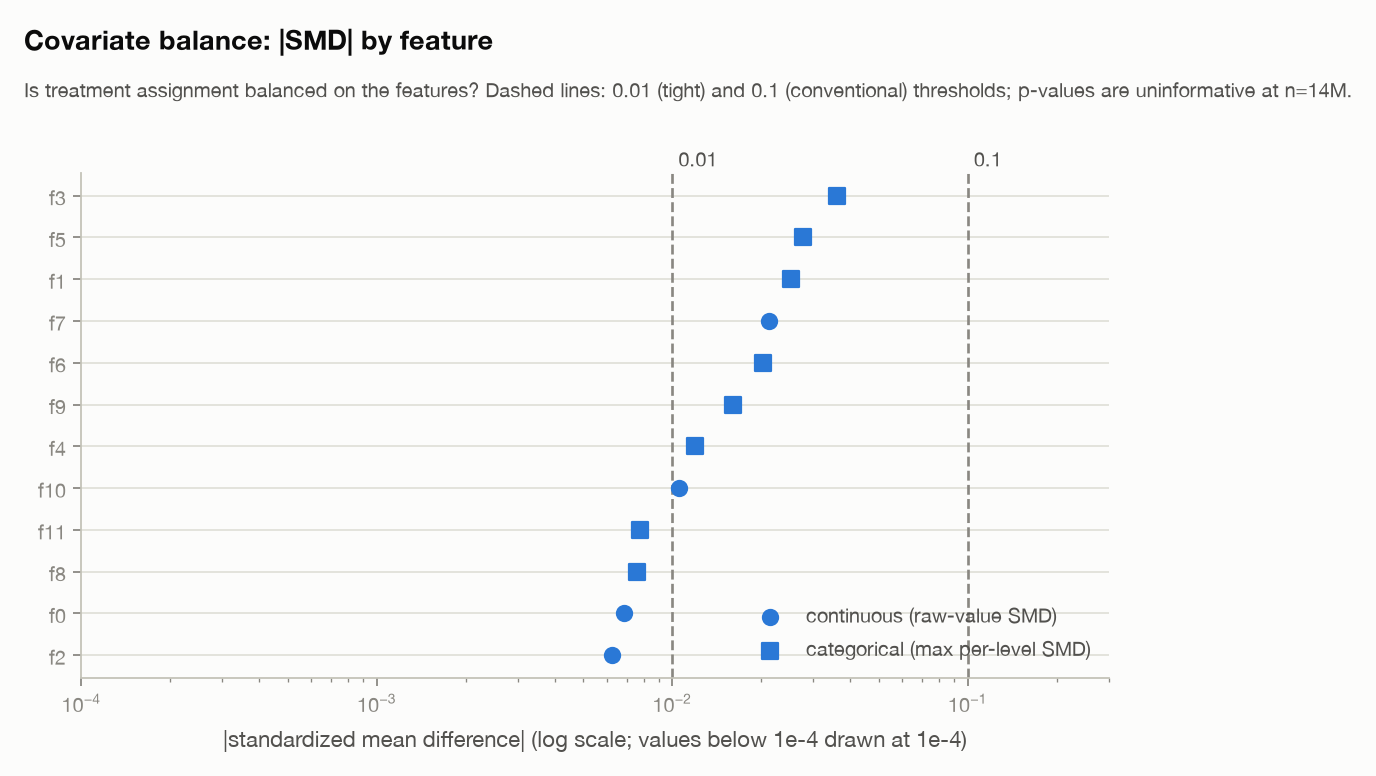

With n=13,979,592 rows even negligible imbalance gives tiny p-values (12 of 12 features have p<0.05), so judge balance by effect size. The largest |SMD| is 0.0362 (f3), within the conventional 0.1 threshold. A perfectly randomized comparison at this n would show |SMD| of order 0.0007 (sqrt(1/n_T+1/n_C)); observed imbalances of 48x that scale are therefore small in size but not sampling noise. Likely cause (interpretation, not documented): the benchmark pools several advertiser tests that were re-sampled to a common treatment ratio, so covariate mix can differ slightly by arm. Downstream causal estimators adjust for covariates.


,feature,type,mean_treated,mean_control,smd,smd_basis,ks_stat,ks_pvalue,chi2_stat,chi2_pvalue,cramers_v,n_levels_tested
3,f3,categorical,4.169,4.233,0.03618,max |per-level indicator SMD|,NaN,NaN,"4,156",0,0.01724,105
5,f5,categorical,4.027,4.039,0.02775,max |per-level indicator SMD|,NaN,NaN,"1,628",0,0.01079,15
1,f1,categorical,10.07,10.07,0.02512,max |per-level indicator SMD|,NaN,NaN,"1,070",8.257e-227,0.008749,8
7,f7,continuous,5.106,5.08,0.02127,raw value,0.006099,5.198e-58,NaN,NaN,NaN,NaN
6,f6,categorical,-4.183,-4,0.0202,max |per-level indicator SMD|,NaN,NaN,"3,824",0,0.01654,218
9,f9,categorical,16.05,15.89,0.01599,max |per-level indicator SMD|,NaN,NaN,"1,208",8.73e-157,0.009297,169
4,f4,categorical,10.34,10.34,0.01195,max |per-level indicator SMD|,NaN,NaN,266.6,1.845e-44,0.004367,22
10,f10,continuous,5.334,5.332,0.01056,raw value,0.002415,1.882e-09,NaN,NaN,NaN,NaN
11,f11,categorical,-0.171,-0.1709,0.00774,max |per-level indicator SMD|,NaN,NaN,127.7,5.116e-22,0.003022,12
8,f8,categorical,3.933,3.935,0.007604,max |per-level indicator SMD|,NaN,NaN,"1,545",2.098e-160,0.01051,318


In [7]:
fig("eda_balance_love")
bal = table("eda_balance").sort_values("smd", key=abs, ascending=False)
print(eda["balance"]["interpretation"] if "interpretation" in eda["balance"] else "")
bal.head(12)

Every standardized difference is below the conventional 0.1 threshold, but at 14M rows the pure-randomization noise
level is about 0.0008, and the largest differences are ~40x that. The statistical-analysis and causal notebooks
show that this small imbalance is correlated with the outcomes and matters for the effect estimates.

## Distributions, correlations and association with conversion

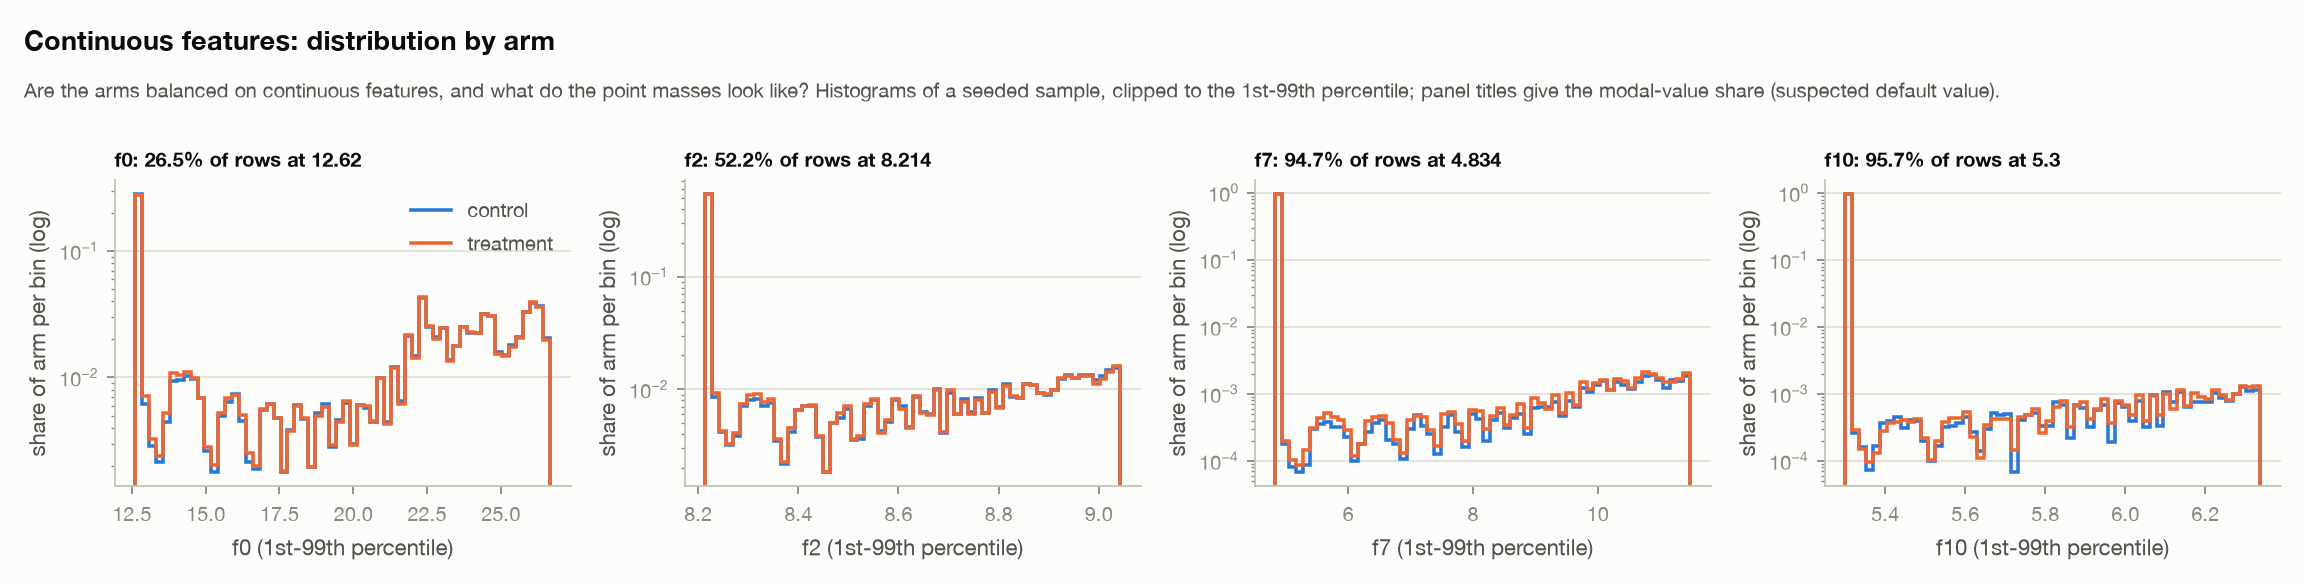

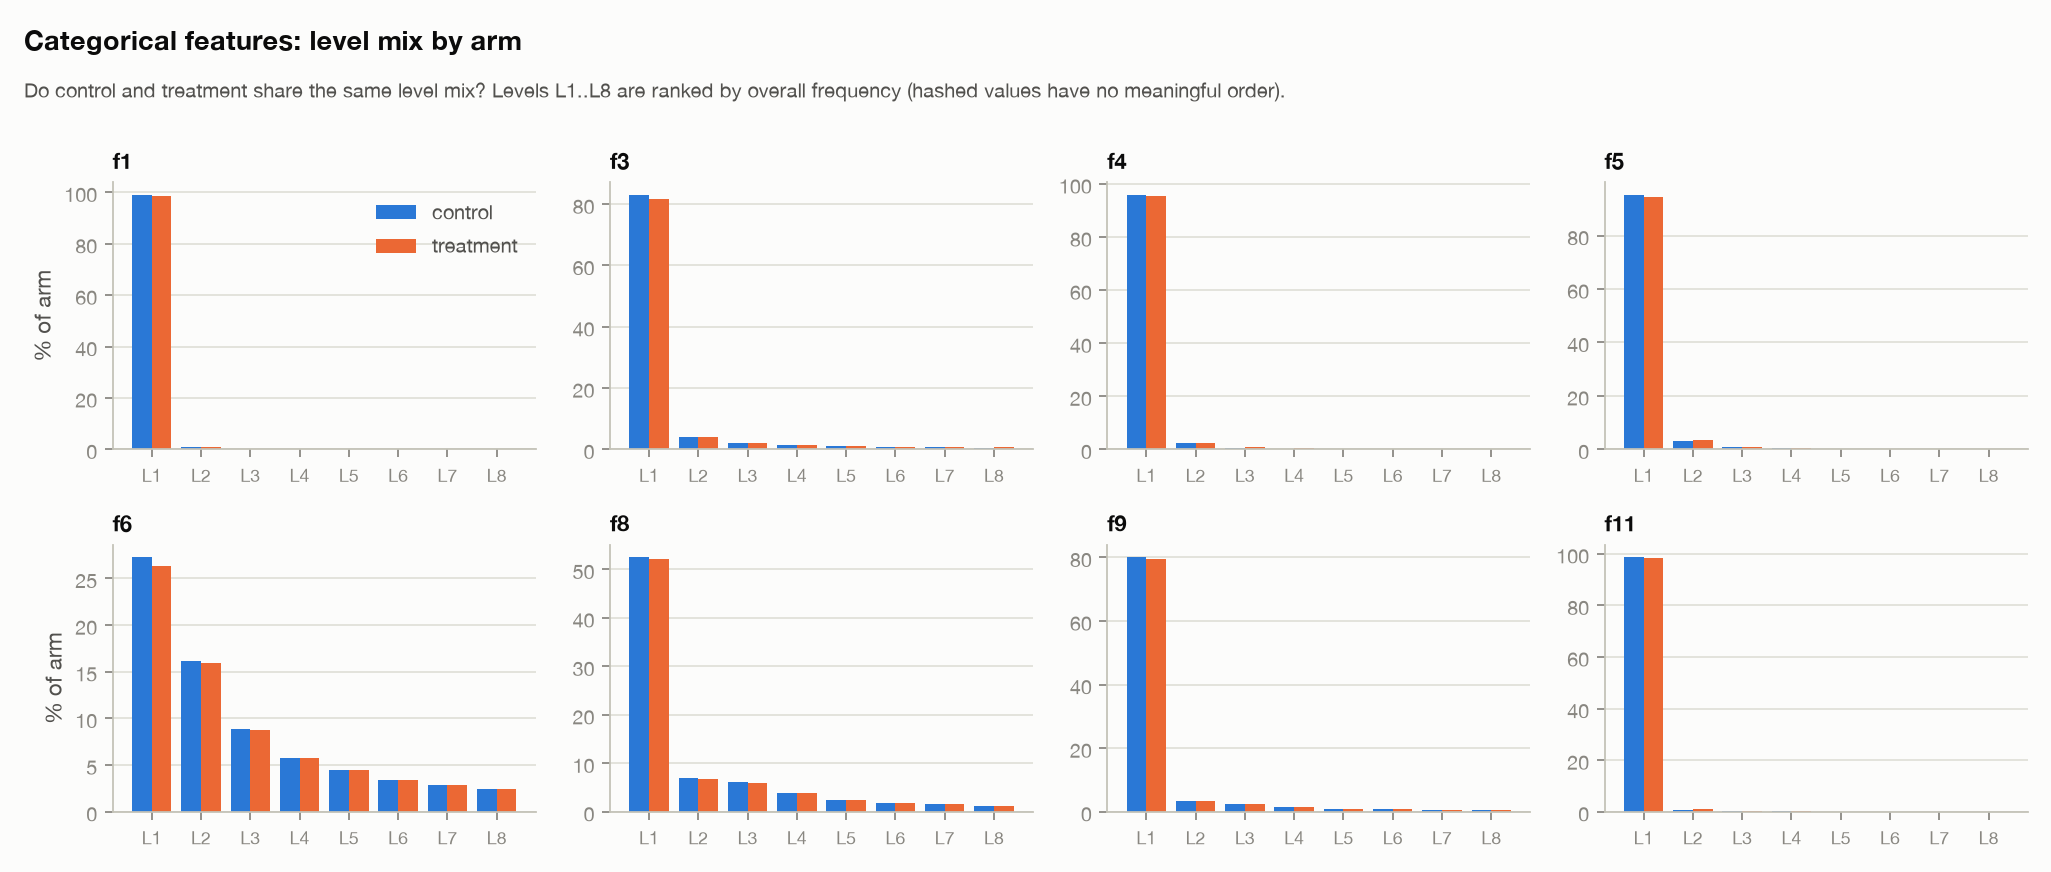

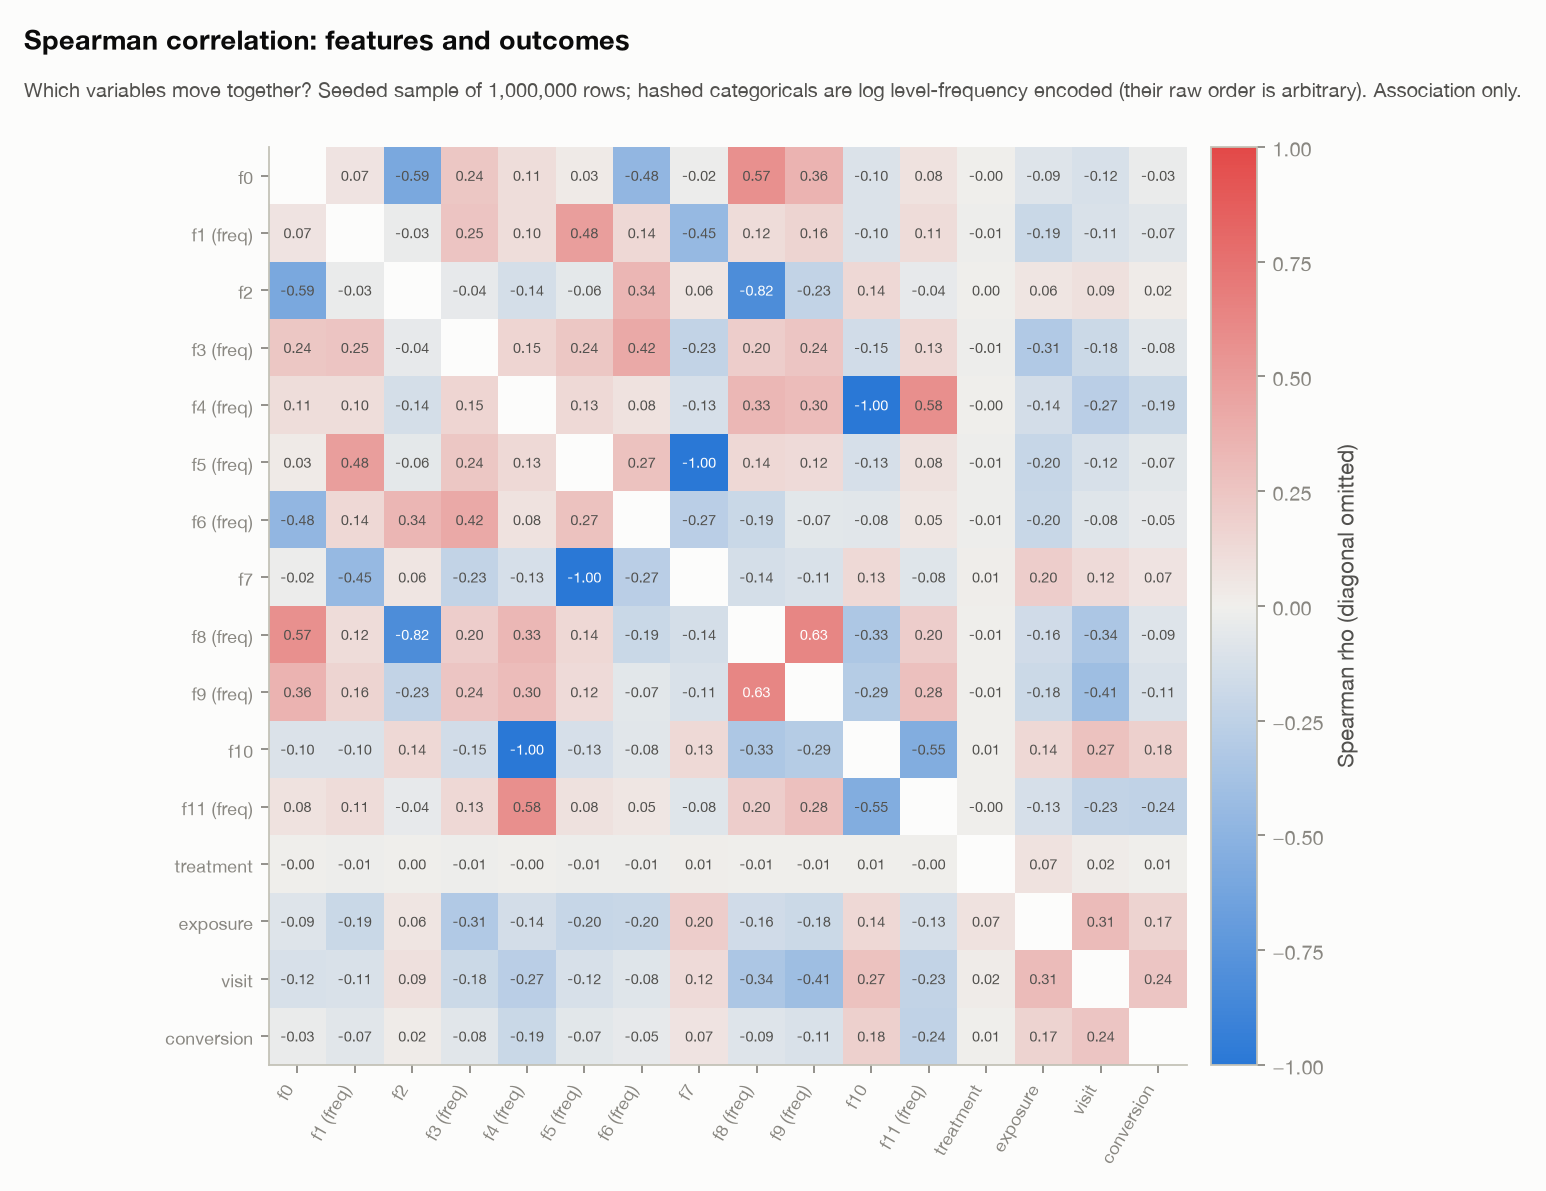

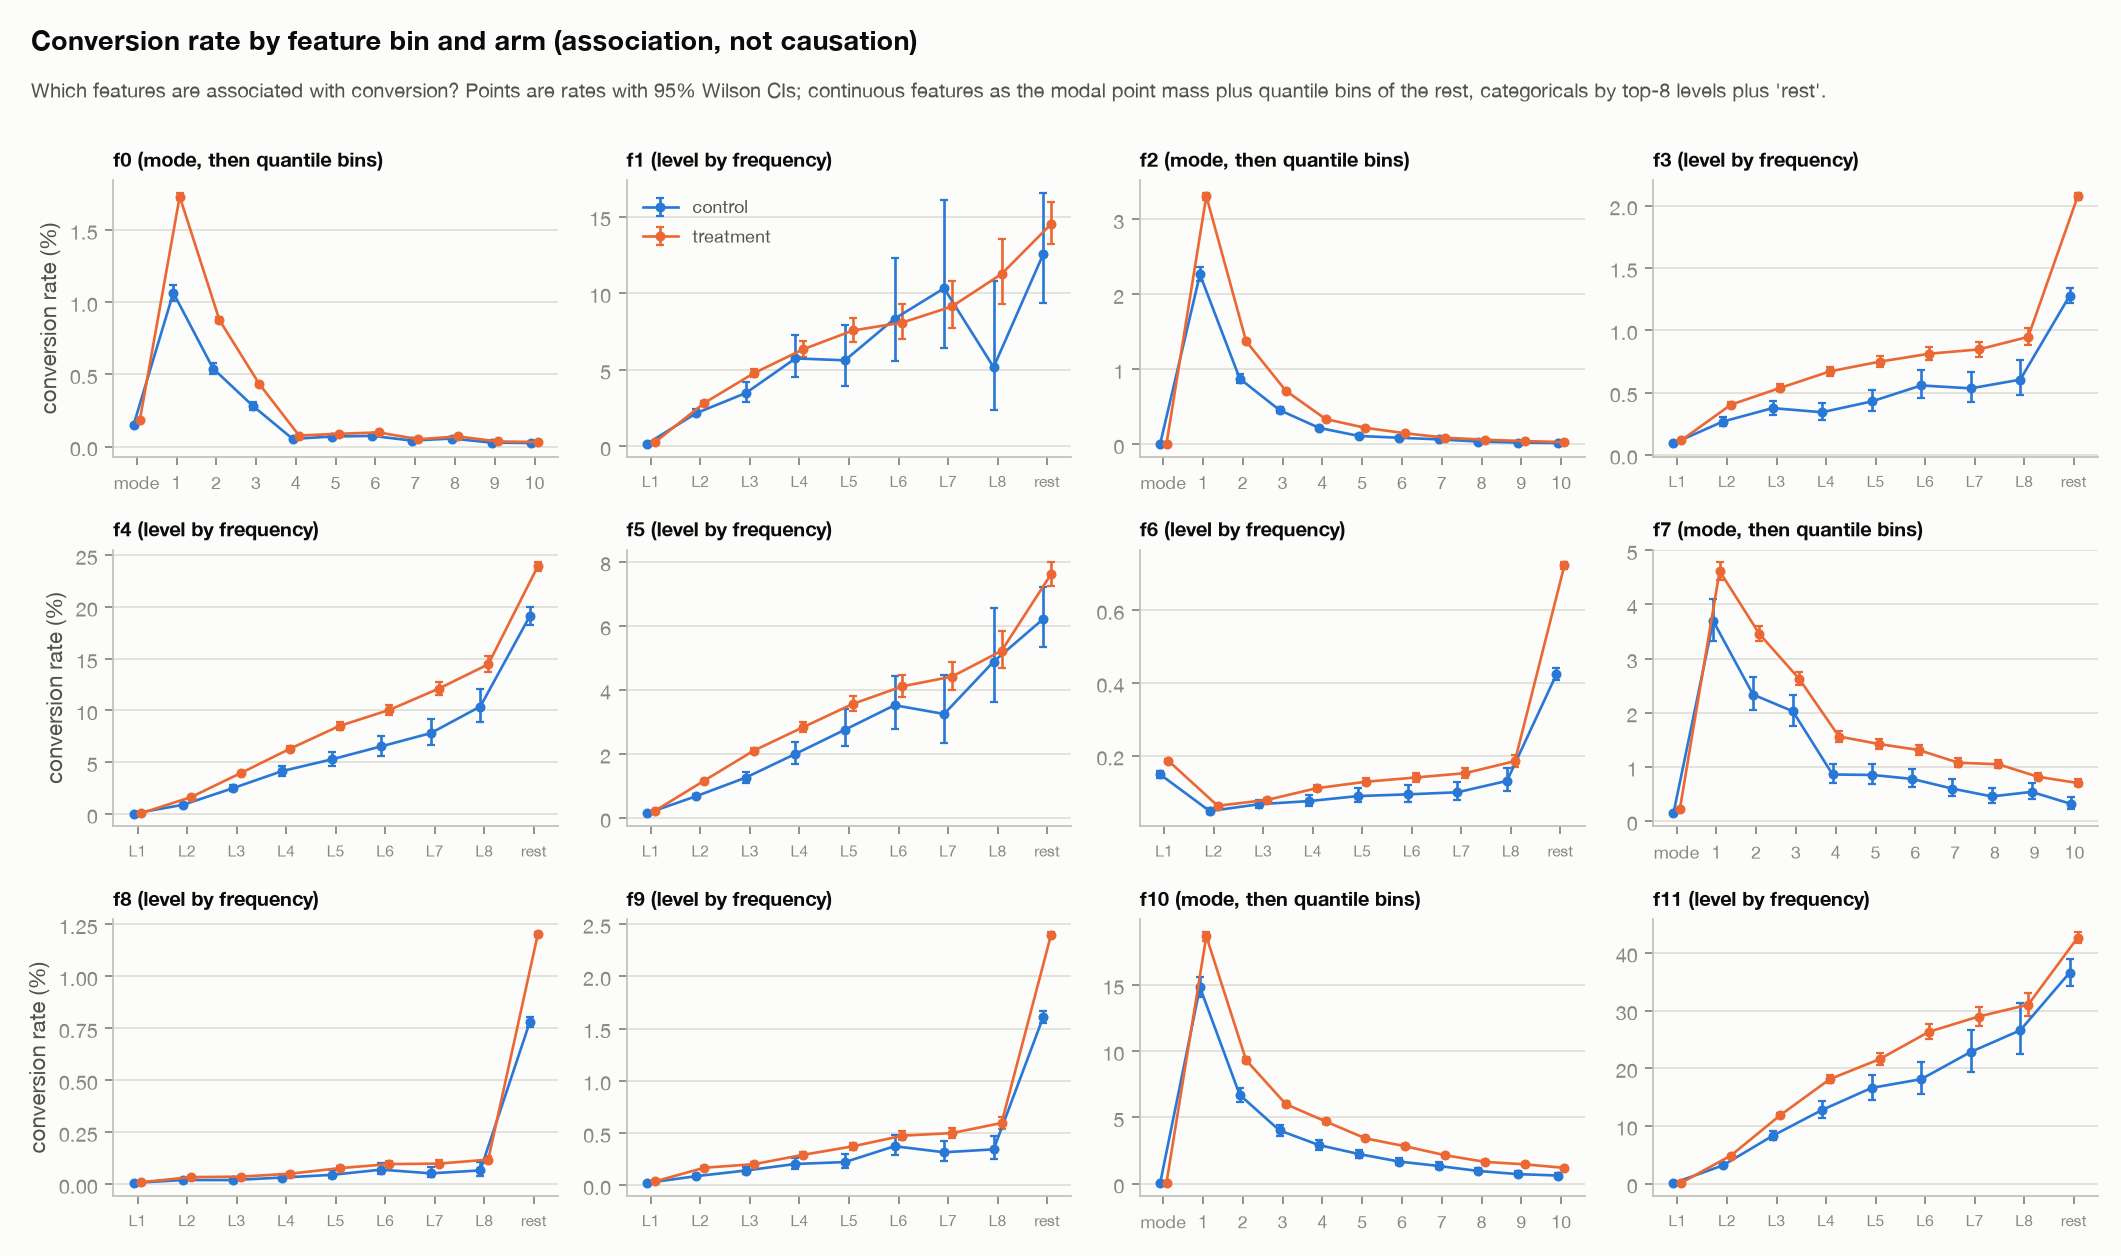

In [8]:
fig("eda_continuous_by_arm"); fig("eda_categorical_by_arm"); fig("eda_correlation"); fig("eda_conversion_by_feature")